In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import lal as _lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.injection import SignalInjector

/tmp/ipykernel_92519/3662997050.py:5: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']


## SimulationConfig

In [2]:
config = SimulationConfig()

print("sampling_frequency (Hz):", config.sampling_frequency)
print("duration (s):", config.duration)
print("delta_t (s):", config.delta_t)
print("length:", config.length)
print("delta_f (Hz):", config.delta_f)
print("flength:", config.flength)

sampling_frequency (Hz): 4096.0
duration (s): 4.0
delta_t (s): 0.000244140625
length: 16384
delta_f (Hz): 0.25
flength: 8193


## CBCParameters

In [3]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=40.0,
    distance=500.0,
    inclination=np.pi / 3,
    ra=1.2,
    dec=0.4,
    spin_1z=0.3,
    spin_2z=-0.2,
)

print(params)
print("mass_1 (Msun):", params.mass_1)
print("mass_2 (Msun):", params.mass_2)
print("total_mass (Msun):", params.total_mass)
print("chirp_mass (Msun):", params.chirp_mass)
print("chi_eff:", params.chi_eff)

CBCParameters(mass_1=40.0, mass_2=20.0, distance=500.0, inclination=1.0471975511965976, ra=1.2, dec=0.4, spin_1z=-0.2, spin_2z=0.3)
mass_1 (Msun): 40.0
mass_2 (Msun): 20.0
total_mass (Msun): 60.0
chirp_mass (Msun): 24.334573675728226
chi_eff: -0.03333333333333333


## ParameterSampler

In [4]:
sampler = ParameterSampler(rng=np.random.default_rng(42))
samples = sampler.sample_many(50000)

print(type(samples[0]))
print(samples[0])

mass_1 = np.array([s.mass_1 for s in samples])
mass_2 = np.array([s.mass_2 for s in samples])
inclinations = np.array([s.inclination for s in samples])
ras = np.array([s.ra for s in samples])
decs = np.array([s.dec for s in samples])

print(np.all(mass_1 >= mass_2))
print(ras.min(), ras.max())
print(decs.min(), decs.max())
print(inclinations.min(), inclinations.max())

<class 'src.parameters.CBCParameters'>
CBCParameters(mass_1=70.78626412725689, mass_2=42.30466737892445, distance=4321.270015574636, inclination=np.float64(1.1650157632181057), ra=0.5917337285168199, dec=np.float64(1.2572466191009846), spin_1z=0.5222794039807059, spin_2z=0.5721286105539076)
True
2.9236616297589228e-05 6.283080156358749
-1.5558382454793735 1.5634006339527045
0.009587441437286907 3.1304001449481835


### Isotropic checks for cos(i) and sin(dec)

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_92519/1952523643.py:7: SyntaxWarning: invalid escape sequence '\i'
  ax[0].set_title(f"cos($\iota$)")


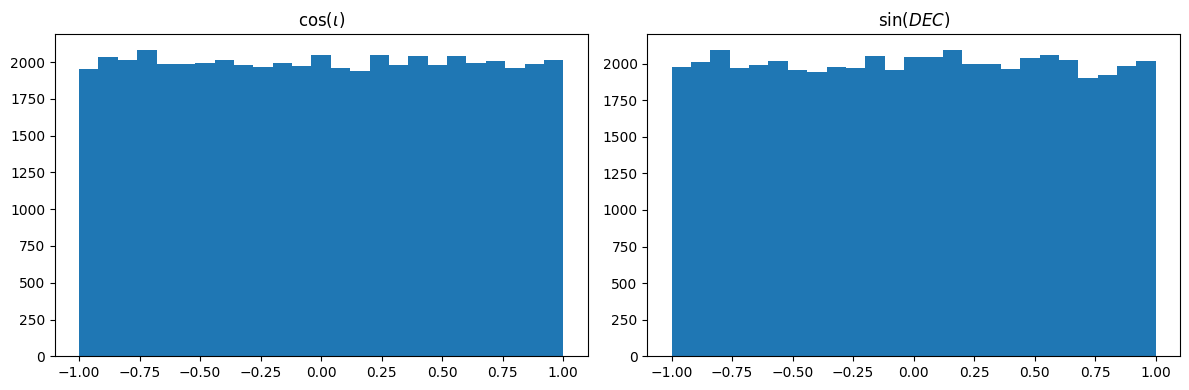

In [5]:
cos_i = np.cos(inclinations)
sin_dec = np.sin(decs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cos_i, bins=25)
ax[0].set_title(f"cos($\iota$)")

ax[1].hist(sin_dec, bins=25)
ax[1].set_title(f"sin($\tDEC$)")

plt.tight_layout()
plt.show()

## SignalInjector

Available detectors: ['T1', 'V0', 'V1', 'G1', 'H2', 'H1', 'L1', 'I1', 'C1', 'E1', 'E2', 'E3', 'E0', 'K1', 'U1', 'A1', 'O1', 'X1', 'N1', 'B1']
InjectionResult(strain=<pycbc.types.timeseries.TimeSeries object at 0x74b771478710>, injection_time=np.float64(1.4931640625), injection_index=np.int64(6116))


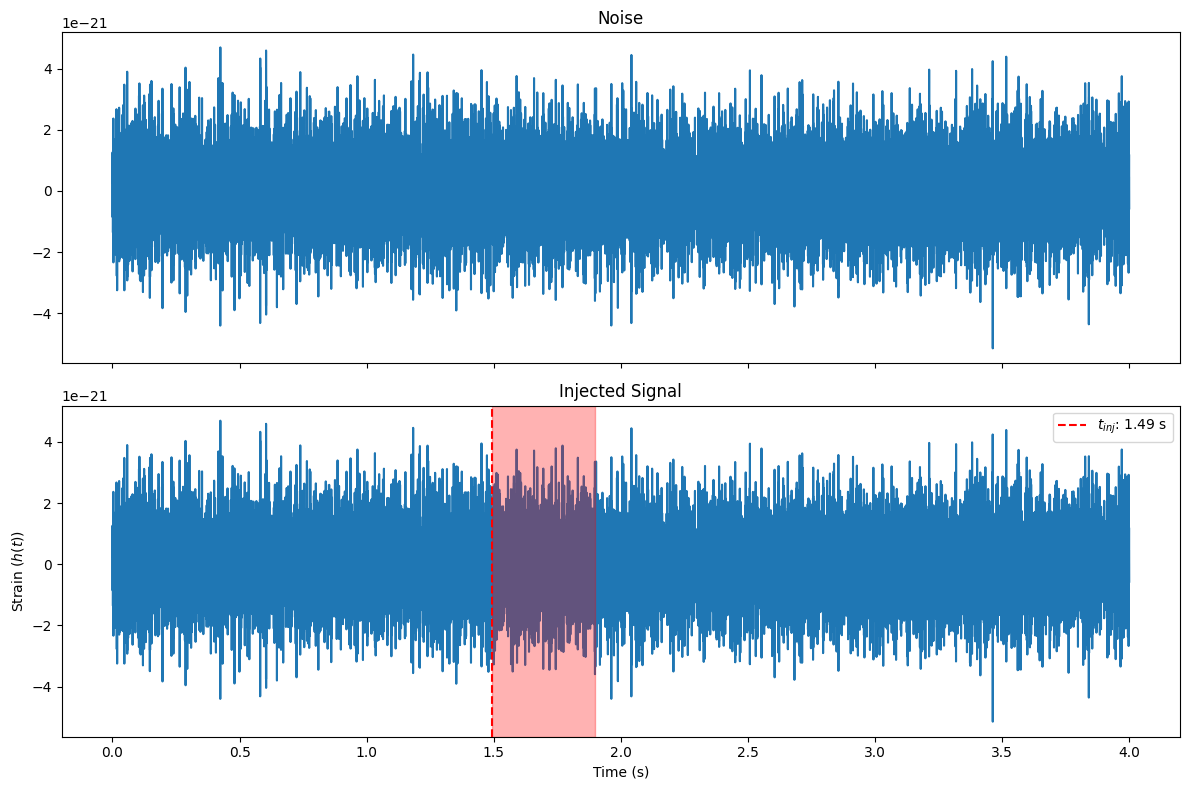

In [6]:
from src.noise import NoiseModel
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector

import lal as _lal

noise_model = NoiseModel(config=config)
noise = noise_model.sample(detector_name="V1")

waveform_generator = WaveformGenerator(config=config)
hp, hc = waveform_generator.generate(parameters=params)

detector_projector = DetectorProjector()
projected_signal = detector_projector.project(h_plus=hp, h_cross=hc, parameters=params)

signal_injector = SignalInjector(config=config)
injected_signal = signal_injector.inject(strain=noise, signal=projected_signal["V1"])

############### PLOTTING ###############

print(injected_signal)
t = np.arange(config.length) * config.delta_t

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, noise)   
ax[0].set_title("Noise")


ax[1].plot(t, injected_signal.strain)
ax[1].set_title("Injected Signal")
# Band with the duration of the signal above the injected signal plot
ax[1].axvspan(
    injected_signal.injection_time,
    injected_signal.injection_time + len(projected_signal["V1"])*projected_signal["V1"].delta_t,
    color='red',
    alpha=0.3,
    zorder=2)
ax[1].axvline(injected_signal.injection_time, color='red', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()



## SignalProcessor

In [7]:
from src.processing import SignalProcessor

processor = SignalProcessor(
    config=config,
    apply_whitening=True,
    apply_lowpass=True,
    apply_highpass=True,
    lowpass_frequency=350.0,
    highpass_frequency=30.0,
)



processed_signal = processor.process(injected_signal.strain)
print(type(processed_signal))
print(len(injected_signal.strain), len(processed_signal))
print("injected_signal.delta_f:",injected_signal.strain.delta_f)
print("injected_signal.delta_t:",injected_signal.strain.delta_t)
print("processed_signal.delta_f:",processed_signal.delta_f)
print("processed_signal.duration:",processed_signal.duration)
print("injected_signal.strain.duration:",injected_signal.strain.duration)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("crop left time:", processed_signal.start_time - injected_signal.strain.start_time)

left_crop_samples = int(((processed_signal.start_time - injected_signal.strain.start_time) / processed_signal.delta_t))
print("left_crop_samples:", left_crop_samples)



<class 'pycbc.types.timeseries.TimeSeries'>
16384 8875
injected_signal.delta_f: 0.25
injected_signal.delta_t: 0.000244140625
processed_signal.delta_f: 0.4615211267605634
processed_signal.duration: 2.166748046875
injected_signal.strain.duration: 4.0
original start_time: 0
processed start_time: 0.916503906
crop left time: 0.916503906
left_crop_samples: 3753


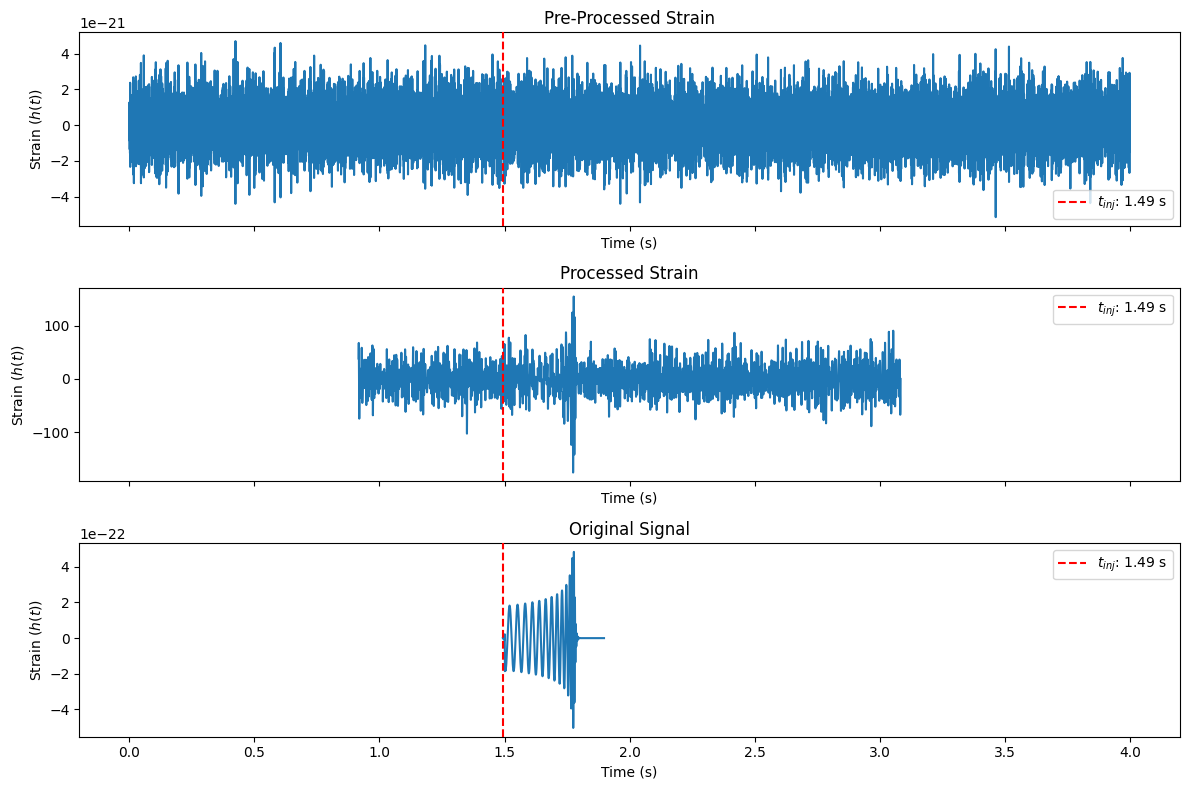

In [ ]:
############### PLOTTING ###############

t = np.arange(config.length) * config.delta_t
t_processed = np.arange(len(processed_signal)) * processed_signal.delta_t + processed_signal.start_time
t_projected = np.arange(len(projected_signal["V1"])) * projected_signal["V1"].delta_t + injected_signal.injection_time

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, injected_signal.strain)  
ax[0].plot(t_projected, projected_signal["V1"], 'r', '--', alpha=0.7, label="Original Signal") 
ax[0].set_title("Pre-Processed Strain")
ax[0].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain ($h(t)$)")
ax[0].legend()

ax[1].plot(t_processed, processed_signal)
ax[1].set_title("Processed Strain")
ax[1].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()